<a href="https://colab.research.google.com/github/manastasijas-pixel/Netology-project/blob/main/FEML_7_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D1%8B_%D1%86%D0%B2%D0%B5%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В домашнем задании нужно сократить число цветов в палитре изображения. Картинку для выполнения работы можно выбрать любую, главное условие – наличие на ней разных цветов, для того, чтобы результат работы моделей был заметен.
Для выполнения работы необходимо выделить кластеры в пространстве RGB, объекты соответствуют пикселям изображения. После выделения кластеров все пиксели, отнесенные в один кластер, заполняются одним цветом. Цвет – центроид соответствующего кластера.

In [ ]:
pip install opencv-python

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

In [ ]:
import matplotlib.pyplot as plt
import cv2
import skimage

def draw_picture(image, title,bgr=True):
    if bgr:
        b, g, r = cv2.split(image)
        image = cv2.merge([r, g, b])
    plt.figure(figsize=(7, 5))
    plt.axis('off')
    plt.imshow(image,cmap='viridis')
    plt.title(title)
    plt.show()

Saving pictures.jpg to pictures (2).jpg


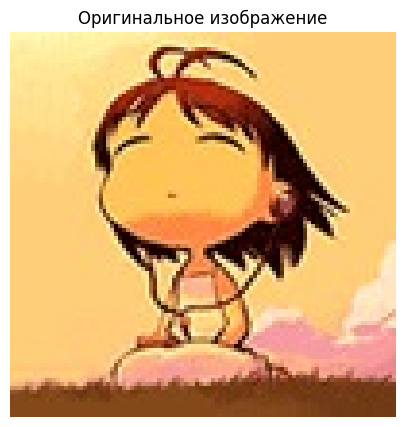

In [ ]:
from google.colab import files
#чтобы загрузить файлы с данными в блокнот/ Вызвать команду столько раз, сколько файлов надо загрузить
dates = files.upload()
img_t = cv2.imread('pictures.jpg')
draw_picture(img_t, 'Оригинальное изображение')

In [ ]:
# Преобразуем массив для обучения модели
# Преобразуйте изображение в формат RGB (если оно в формате BGR)
img_t_rgb = cv2.cvtColor(img_t, cv2.COLOR_BGR2RGB)
# Преобразуйте изображение в двумерный массив (число пикселей x число каналов)
img_tt = img_t_rgb.reshape((-1, 3))

In [ ]:
from skimage.metrics import structural_similarity as ssim

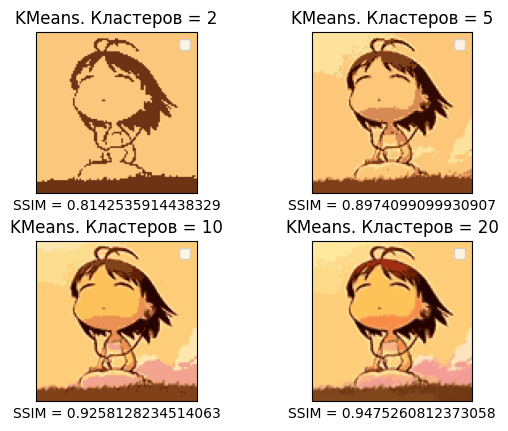

In [ ]:
col_clasters = [2,5,10,20]
p = 1
for k in col_clasters:
    clf_kmeans = KMeans(n_clusters=k)
    clusters_kmeans = clf_kmeans.fit_predict(img_tt)
    # Получите метки кластеров
    labels = clf_kmeans.labels_

    segmented_img = img_tt.copy()
    # Нахождение среднего цвета для каждого кластера
    for i in range(k):
      # присвоим всем пикселям кластера  значение центрального
      segmented_img[labels == i] = clf_kmeans.cluster_centers_[i]

    # Преобразуйте метки обратно в форму изображения
    segmented_img = segmented_img.reshape(img_t_rgb.shape)
    plt.subplot(2, 2,p)
    plt.subplots_adjust(wspace=0.25, hspace=0.3)
    #plt.axis('off')
    p=p+1
    plt.title(f'KMeans. Кластеров = {k}')
    ax = plt.gca()
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    plt.xlabel(f'SSIM = {ssim(img_t_rgb, segmented_img.reshape(100,100,3), channel_axis=2)}')
    plt.imshow(segmented_img.reshape(100,100,3))
    #draw_picture(segmented_img,f'Количество кластеров = {k}')
    #print(f'SSIM = {ssim(img_t_rgb, segmented_img.reshape(100,100,3), channel_axis=2)}')

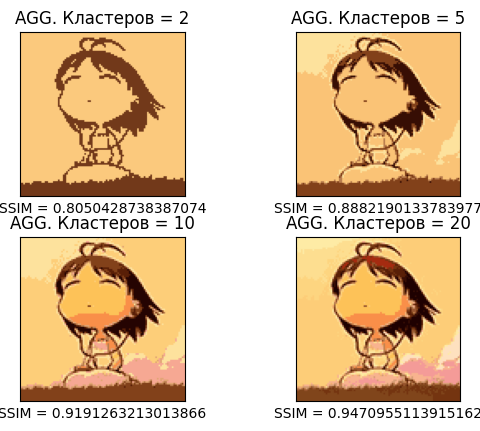

In [ ]:
col_clasters = [2, 5, 10, 20]
p=1
for k in col_clasters:
    clf_agg = AgglomerativeClustering(n_clusters=k,  linkage='ward')
    clusters_agg = clf_agg.fit_predict(img_tt)
    clf_agg

    # Получите метки кластеров
    labels = clf_agg.labels_

    segmented_img = img_tt.copy()
    # Нахождение среднего цвета для каждого кластера
    for i in range(k):
      # присвоим кластерам средний цвет кластера. я ненашла как найти центры
      segmented_img[labels == i] = np.mean(segmented_img[labels == i], axis=0)

    # Преобразуйте метки обратно в форму изображения
    segmented_img = segmented_img.reshape(img_t_rgb.shape)
    plt.subplot(2, 2,p)
    plt.subplots_adjust(wspace=0.25, hspace=0.25)
    p=p+1
    ax = plt.gca()
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    plt.xlabel(f'SSIM = {ssim(img_t_rgb, segmented_img.reshape(100,100,3), channel_axis=2)}')
    plt.title(f'AGG. Кластеров = {k}')
    plt.imshow(segmented_img.reshape(100,100,3))

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


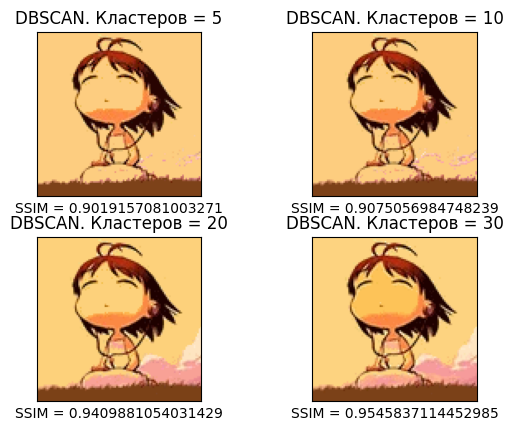

In [ ]:
#Посчитаем модель AgglomerativeClustering на разных количествах кластеров
col_clasters = [5, 10, 20,30]
p=1
for k in col_clasters:
    clf_dbs = DBSCAN(eps=5,min_samples =k)
    clusters_dbs = clf_dbs.fit_predict(img_tt)

    # Получите метки кластеров
    labels = clf_dbs.labels_

    segmented_img = img_tt.copy()
    # Нахождение среднего цвета для каждого кластера
    for i in range(k):
      # присвоим кластерам средний цвет кластера. я ненашла как найти центры
      segmented_img[labels == i] = np.mean(segmented_img[labels == i], axis=0)

    # Преобразуйте метки обратно в форму изображения
    segmented_img = segmented_img.reshape(img_t_rgb.shape)
    plt.subplot(2, 2,p)
    plt.subplots_adjust(wspace=0.25, hspace=0.25)
    #plt.axis('off')
    ax = plt.gca()
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    plt.xlabel(f'SSIM = {ssim(img_t_rgb, segmented_img.reshape(100,100,3), channel_axis=2)}')
    p=p+1
    plt.title(f'DBSCAN. Кластеров = {k}')
    plt.imshow(segmented_img.reshape(100,100,3))

In [ ]:
С увеличением количества кластеров все модели хорошо работают. слжно сказать какие лучше